In [ ]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["AAPL", "MSFT", "JPM", "GS", "BLK"]

data = yf.download(
    tickers,
    start="2025-09-22",
    end="2026-09-22",
    auto_adjust=True,
    progress=False
)

prices = data["Close"].dropna()

# Historical daily returns
returns = prices.pct_change().dropna()

# Equal portfolio weights
weights = np.array([0.20] * 5)

# Daily-rebalanced portfolio returns
portfolio_returns = returns @ weights

display((returns.head() * 100).round(2))

print("Observations:", len(portfolio_returns))

In [1]:
print("Day 6 kernel is working!")

Day 6 kernel is working!


In [2]:
returns = prices.pct_change().dropna()

weights = np.array([0.20] * 5)

portfolio_returns = returns @ weights

print("Observations:", len(portfolio_returns))

NameError: name 'prices' is not defined

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv(
    "five_stock_prices.csv",
    index_col=0,
    parse_dates=True
)

prices = prices[["AAPL", "MSFT", "JPM", "GS", "BLK"]].dropna()

print("Trading days:", len(prices))
display(prices.head())

Trading days: 250


,AAPL,MSFT,JPM,GS,BLK
Date,,,,,
2025-09-23,253.493591,505.074463,306.869354,790.766968,1108.070068
2025-09-24,251.381409,505.986908,307.536621,777.144836,1104.378906
2025-09-25,255.924637,502.892334,307.566071,779.429932,1123.284790
2025-09-26,254.519806,507.286194,310.127045,787.030518,1132.253052
2025-09-29,253.493591,510.400513,309.764008,788.609436,1150.963501


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate historical daily stock returns
returns = prices.pct_change().dropna()

# Allocate 20% to each of the five stocks
weights = np.array([0.20] * 5)

# Daily returns of an equally weighted, daily-rebalanced portfolio
portfolio_returns = returns @ weights

print("Return observations:", len(portfolio_returns))
print(f"Average daily return: {portfolio_returns.mean():.4%}")
print(f"Daily volatility: {portfolio_returns.std():.4%}")

Return observations: 249
Average daily return: 0.0637%
Daily volatility: 1.1484%


In [6]:
initial_investment = 10000
confidence_level = 0.95

# Historical 5th-percentile return
var_return = np.percentile(portfolio_returns, 5)

# Average return in the worst 5% of observations
cvar_return = portfolio_returns[
    portfolio_returns <= var_return
].mean()

print(f"95% Daily VaR: {-var_return:.2%}")
print(f"95% Daily CVaR: {-cvar_return:.2%}")

print(f"VaR in dollars: ${-var_return * initial_investment:,.2f}")
print(f"CVaR in dollars: ${-cvar_return * initial_investment:,.2f}")

95% Daily VaR: 2.03%
95% Daily CVaR: 2.52%
VaR in dollars: $203.39
CVaR in dollars: $252.17


In [7]:
np.random.seed(42)

simulations = 10000
trading_days = 252
initial_investment = 10000

daily_mean = portfolio_returns.mean()
daily_std = portfolio_returns.std()

# Simulate daily returns
simulated_returns = np.random.normal(
    daily_mean,
    daily_std,
    (trading_days, simulations)
)

# Calculate simulated portfolio values
simulated_values = initial_investment * np.cumprod(
    1 + simulated_returns,
    axis=0
)

final_values = simulated_values[-1]

print(f"Mean final value: ${final_values.mean():,.2f}")
print(f"Median final value: ${np.median(final_values):,.2f}")
print(f"5th-percentile final value: ${np.percentile(final_values, 5):,.2f}")

Mean final value: $11,722.61
Median final value: $11,540.44
5th-percentile final value: $8,558.62


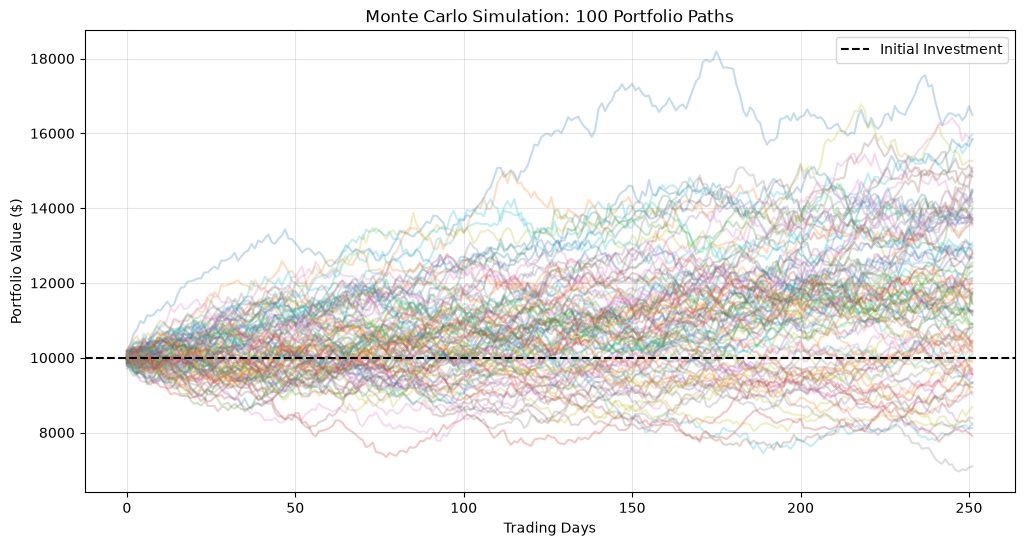

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(simulated_values[:, :100], alpha=0.25)

plt.axhline(
    initial_investment,
    color="black",
    linestyle="--",
    label="Initial Investment"
)

plt.title("Monte Carlo Simulation: 100 Portfolio Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
# Simulated one-year profit or loss
simulated_pnl = final_values - initial_investment

# 5th percentile of simulated P&L
mc_var_threshold = np.percentile(simulated_pnl, 5)

# Average P&L in the worst 5%
mc_cvar = simulated_pnl[
    simulated_pnl <= mc_var_threshold
].mean()

print(f"One-year Monte Carlo VaR (95%): ${-mc_var_threshold:,.2f}")
print(f"One-year Monte Carlo CVaR (95%): ${-mc_cvar:,.2f}")

One-year Monte Carlo VaR (95%): $1,441.38
One-year Monte Carlo CVaR (95%): $2,058.57


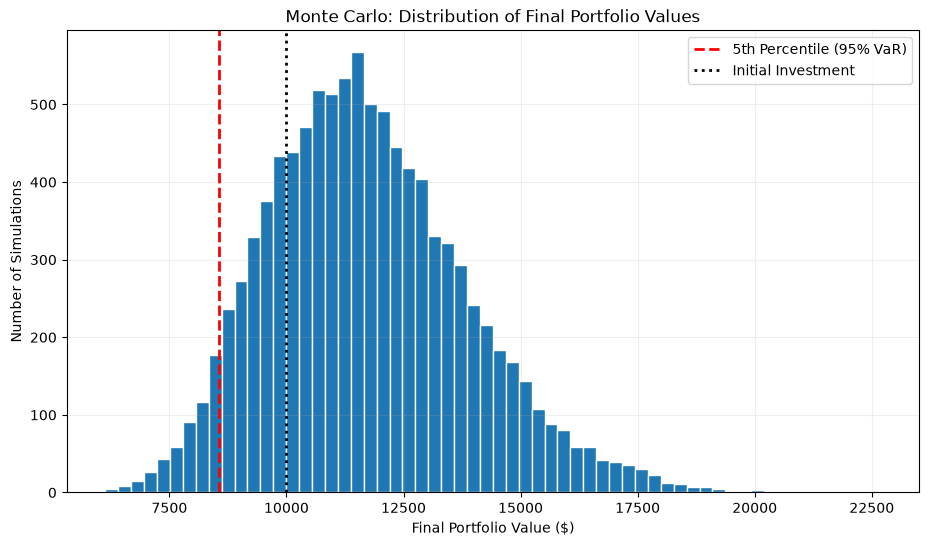

In [10]:
plt.figure(figsize=(11, 6))

plt.hist(final_values, bins=60, edgecolor="white")

plt.axvline(
    np.percentile(final_values, 5),
    color="red",
    linestyle="--",
    linewidth=2,
    label="5th Percentile (95% VaR)"
)

plt.axvline(
    initial_investment,
    color="black",
    linestyle=":",
    linewidth=2,
    label="Initial Investment"
)

plt.title("Monte Carlo: Distribution of Final Portfolio Values")
plt.xlabel("Final Portfolio Value ($)")
plt.ylabel("Number of Simulations")
plt.legend()
plt.grid(alpha=0.2)
plt.show()